# Phase 1: Weight of Evidence (WoE) + Information Value (IV) Analysis

**Project:** Credit Default Risk Modeling  
**Phase:** 1 — Feature Selection & WoE Encoding  

## What & Why?

**Weight of Evidence (WoE)** measures how strongly each category/bin of a feature separates defaulters from non-defaulters.

$$WoE_i = \ln\left(\frac{\%\ Events_i}{\%\ NonEvents_i}\right)$$

**Information Value (IV)** quantifies the total predictive power of a feature.

$$IV = \sum_{i=1}^{n} (\%\ Events_i - \%\ NonEvents_i) \times WoE_i$$

| IV Range    | Predictive Power         |
|-------------|-------------------------|
| < 0.02      | Useless — drop it       |
| 0.02 – 0.1  | Weak                    |
| 0.1 – 0.3   | Medium                  |
| 0.3 – 0.5   | Strong                  |
| > 0.5       | Suspicious (check leakage) |

This is how **real credit scoring systems** select features — not correlation, not feature importance from trees.

## 1 Imports & Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [15]:
# ── Load & Prep (same steps as EDA notebook) ───────────────────────────────
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')   # ← update path if needed

# Rename columns
column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

# Fix target: 1=Default, 0=Good
raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

print(f'Shape: {data.shape}')
print(f'Default Rate: {data["target"].mean()*100:.1f}%')
print('Data ready for WoE/IV analysis!')

Shape: (1000, 21)
Default Rate: 30.0%
Data ready for WoE/IV analysis!


## 2 Define Feature Groups

In [5]:
numeric_cols = [
    'duration_months', 'credit_amount', 'age',
    'installment_rate', 'residence_years',
    'existing_credits', 'dependents'
]

categorical_cols = [
    'checking_account', 'credit_history', 'purpose',
    'savings_account', 'employment_years', 'personal_status',
    'other_debtors', 'property', 'other_installments',
    'housing', 'job', 'telephone', 'foreign_worker'
]

all_features = numeric_cols + categorical_cols
print(f'Total features: {len(all_features)}')

Total features: 20


## 3 WoE + IV Functions

We build this **from scratch** (not using a library) so you truly understand it.

In [16]:
def compute_woe_iv(df, feature, target, bins=10, is_numeric=True):
    """
    Compute WoE and IV for a single feature.

    Parameters:
    -----------
    df         : DataFrame
    feature    : column name
    target     : target column name (1=Default, 0=Good)
    bins       : number of quantile bins (for numeric features)
    is_numeric : True for numeric features, False for categorical

    Returns:
    --------
    woe_df : DataFrame with WoE per bin
    iv     : float — total Information Value
    """
    df = df[[feature, target]].copy()
    total_events     = df[target].sum()          # total defaults
    total_non_events = len(df) - total_events    # total good

    if is_numeric:
        # Bin numeric feature into quantiles
        df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
    else:
        df['bin'] = df[feature]

    # Aggregate by bin
    grouped = df.groupby('bin', observed=True)[target].agg(
        Events='sum',
        Total='count'
    ).reset_index()
    grouped['NonEvents'] = grouped['Total'] - grouped['Events']

    # Avoid division by zero — add small epsilon
    eps = 0.5
    grouped['pct_Events']    = (grouped['Events']    + eps) / (total_events     + eps)
    grouped['pct_NonEvents'] = (grouped['NonEvents'] + eps) / (total_non_events + eps)

    # WoE and IV per bin
    grouped['WoE'] = np.log(grouped['pct_Events'] / grouped['pct_NonEvents'])
    grouped['IV']  = (grouped['pct_Events'] - grouped['pct_NonEvents']) * grouped['WoE']

    # Default rate per bin
    grouped['Default_Rate'] = grouped['Events'] / grouped['Total']

    iv_total = grouped['IV'].sum()

    return grouped[['bin','Total','Events','NonEvents',
                    'Default_Rate','WoE','IV']].round(4), round(iv_total, 4)


def iv_label(iv):
    """Return human-readable IV strength label."""
    if iv < 0.02:  return 'Useless'
    elif iv < 0.1: return 'Weak'
    elif iv < 0.3: return 'Medium'
    elif iv < 0.5: return 'Strong'
    else:          return 'Suspicious'


print('WoE/IV functions defined successfully!')

WoE/IV functions defined successfully!


## 4 Compute IV for ALL Features

In [17]:
iv_results = []

for col in all_features:
    is_num = col in numeric_cols
    try:
        _, iv = compute_woe_iv(data, col, 'target', bins=10, is_numeric=is_num)
        iv_results.append({
            'Feature'  : col,
            'IV'       : iv,
            'Strength' : iv_label(iv),
            'Type'     : 'Numeric' if is_num else 'Categorical'
        })
    except Exception as e:
        print(f'  !!  Skipped {col}: {e}')

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)

print('=== Information Value — All Features ===\n')
print(iv_df.to_string(index=False))

=== Information Value — All Features ===

           Feature     IV   Strength        Type
  checking_account 0.6613 Suspicious Categorical
    credit_history 0.2923     Medium Categorical
   duration_months 0.2439     Medium     Numeric
   savings_account 0.1888     Medium Categorical
           purpose 0.1654     Medium Categorical
          property 0.1122     Medium Categorical
     credit_amount 0.1121     Medium     Numeric
               age 0.1029     Medium     Numeric
           housing 0.0861       Weak Categorical
  employment_years 0.0861       Weak Categorical
other_installments 0.0586       Weak Categorical
   personal_status 0.0450       Weak Categorical
    foreign_worker 0.0393       Weak Categorical
     other_debtors 0.0312       Weak Categorical
  installment_rate 0.0253       Weak     Numeric
               job 0.0090    Useless Categorical
         telephone 0.0063    Useless Categorical
  existing_credits 0.0029    Useless     Numeric
   residence_years 0.0005  

## 5 IV Bar Chart — Feature Ranking

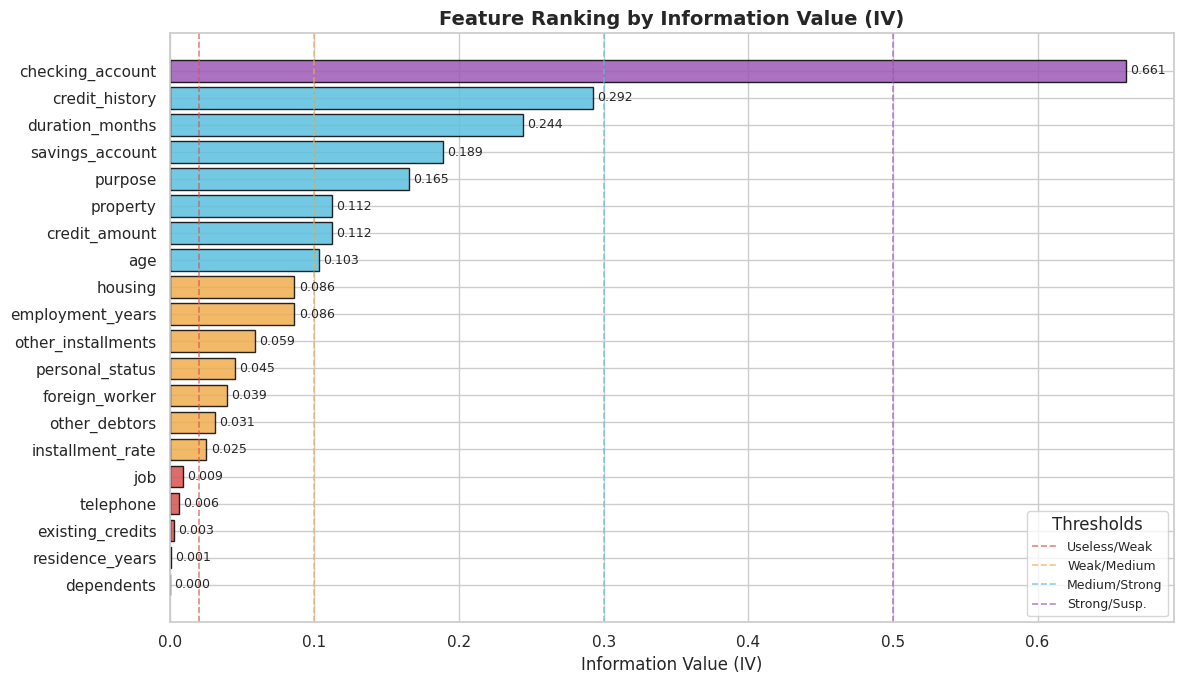

In [8]:
def iv_color(iv):
    if iv < 0.02:  return '#d9534f'   # red   — useless
    elif iv < 0.1: return '#f0ad4e'   # amber — weak
    elif iv < 0.3: return '#5bc0de'   # blue  — medium
    elif iv < 0.5: return '#5cb85c'   # green — strong
    else:          return '#9b59b6'   # purple — suspicious

colors = [iv_color(iv) for iv in iv_df['IV']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(iv_df['Feature'], iv_df['IV'], color=colors, edgecolor='black', alpha=0.85)

# Reference lines
for xval, label, color in [
    (0.02, 'Useless/Weak', '#d9534f'),
    (0.1,  'Weak/Medium',  '#f0ad4e'),
    (0.3,  'Medium/Strong','#5bc0de'),
    (0.5,  'Strong/Susp.', '#9b59b6')
]:
    ax.axvline(xval, linestyle='--', color=color, linewidth=1.2, alpha=0.7, label=label)

# Value labels
for bar, val in zip(bars, iv_df['IV']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title('Feature Ranking by Information Value (IV)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.legend(title='Thresholds', loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6 Feature Selection Based on IV

In [18]:
# Keep features with IV >= 0.02 (weak or above)
selected_features = iv_df[iv_df['IV'] >= 0.02]['Feature'].tolist()
dropped_features  = iv_df[iv_df['IV'] <  0.02]['Feature'].tolist()

print(f' Selected features ({len(selected_features)}):')
for f in selected_features:
    row = iv_df[iv_df['Feature'] == f].iloc[0]
    print(f'   {f:<25}  IV={row["IV"]:.4f}  {row["Strength"]}')

print(f'\n Dropped features ({len(dropped_features)}):')
for f in dropped_features:
    row = iv_df[iv_df['Feature'] == f].iloc[0]
    print(f'   {f:<25}  IV={row["IV"]:.4f}  {row["Strength"]}')

 Selected features (15):
   checking_account           IV=0.6613  Suspicious
   credit_history             IV=0.2923  Medium
   duration_months            IV=0.2439  Medium
   savings_account            IV=0.1888  Medium
   purpose                    IV=0.1654  Medium
   property                   IV=0.1122  Medium
   credit_amount              IV=0.1121  Medium
   age                        IV=0.1029  Medium
   housing                    IV=0.0861  Weak
   employment_years           IV=0.0861  Weak
   other_installments         IV=0.0586  Weak
   personal_status            IV=0.0450  Weak
   foreign_worker             IV=0.0393  Weak
   other_debtors              IV=0.0312  Weak
   installment_rate           IV=0.0253  Weak

 Dropped features (5):
   job                        IV=0.0090  Useless
   telephone                  IV=0.0063  Useless
   existing_credits           IV=0.0029  Useless
   residence_years            IV=0.0005  Useless
   dependents                 IV=0.0000  Usel

## 7 Deep Dive — WoE Charts for Top Features

For each top feature, we plot the WoE per bin AND the default rate.
This tells us exactly **which categories/ranges are risky**.

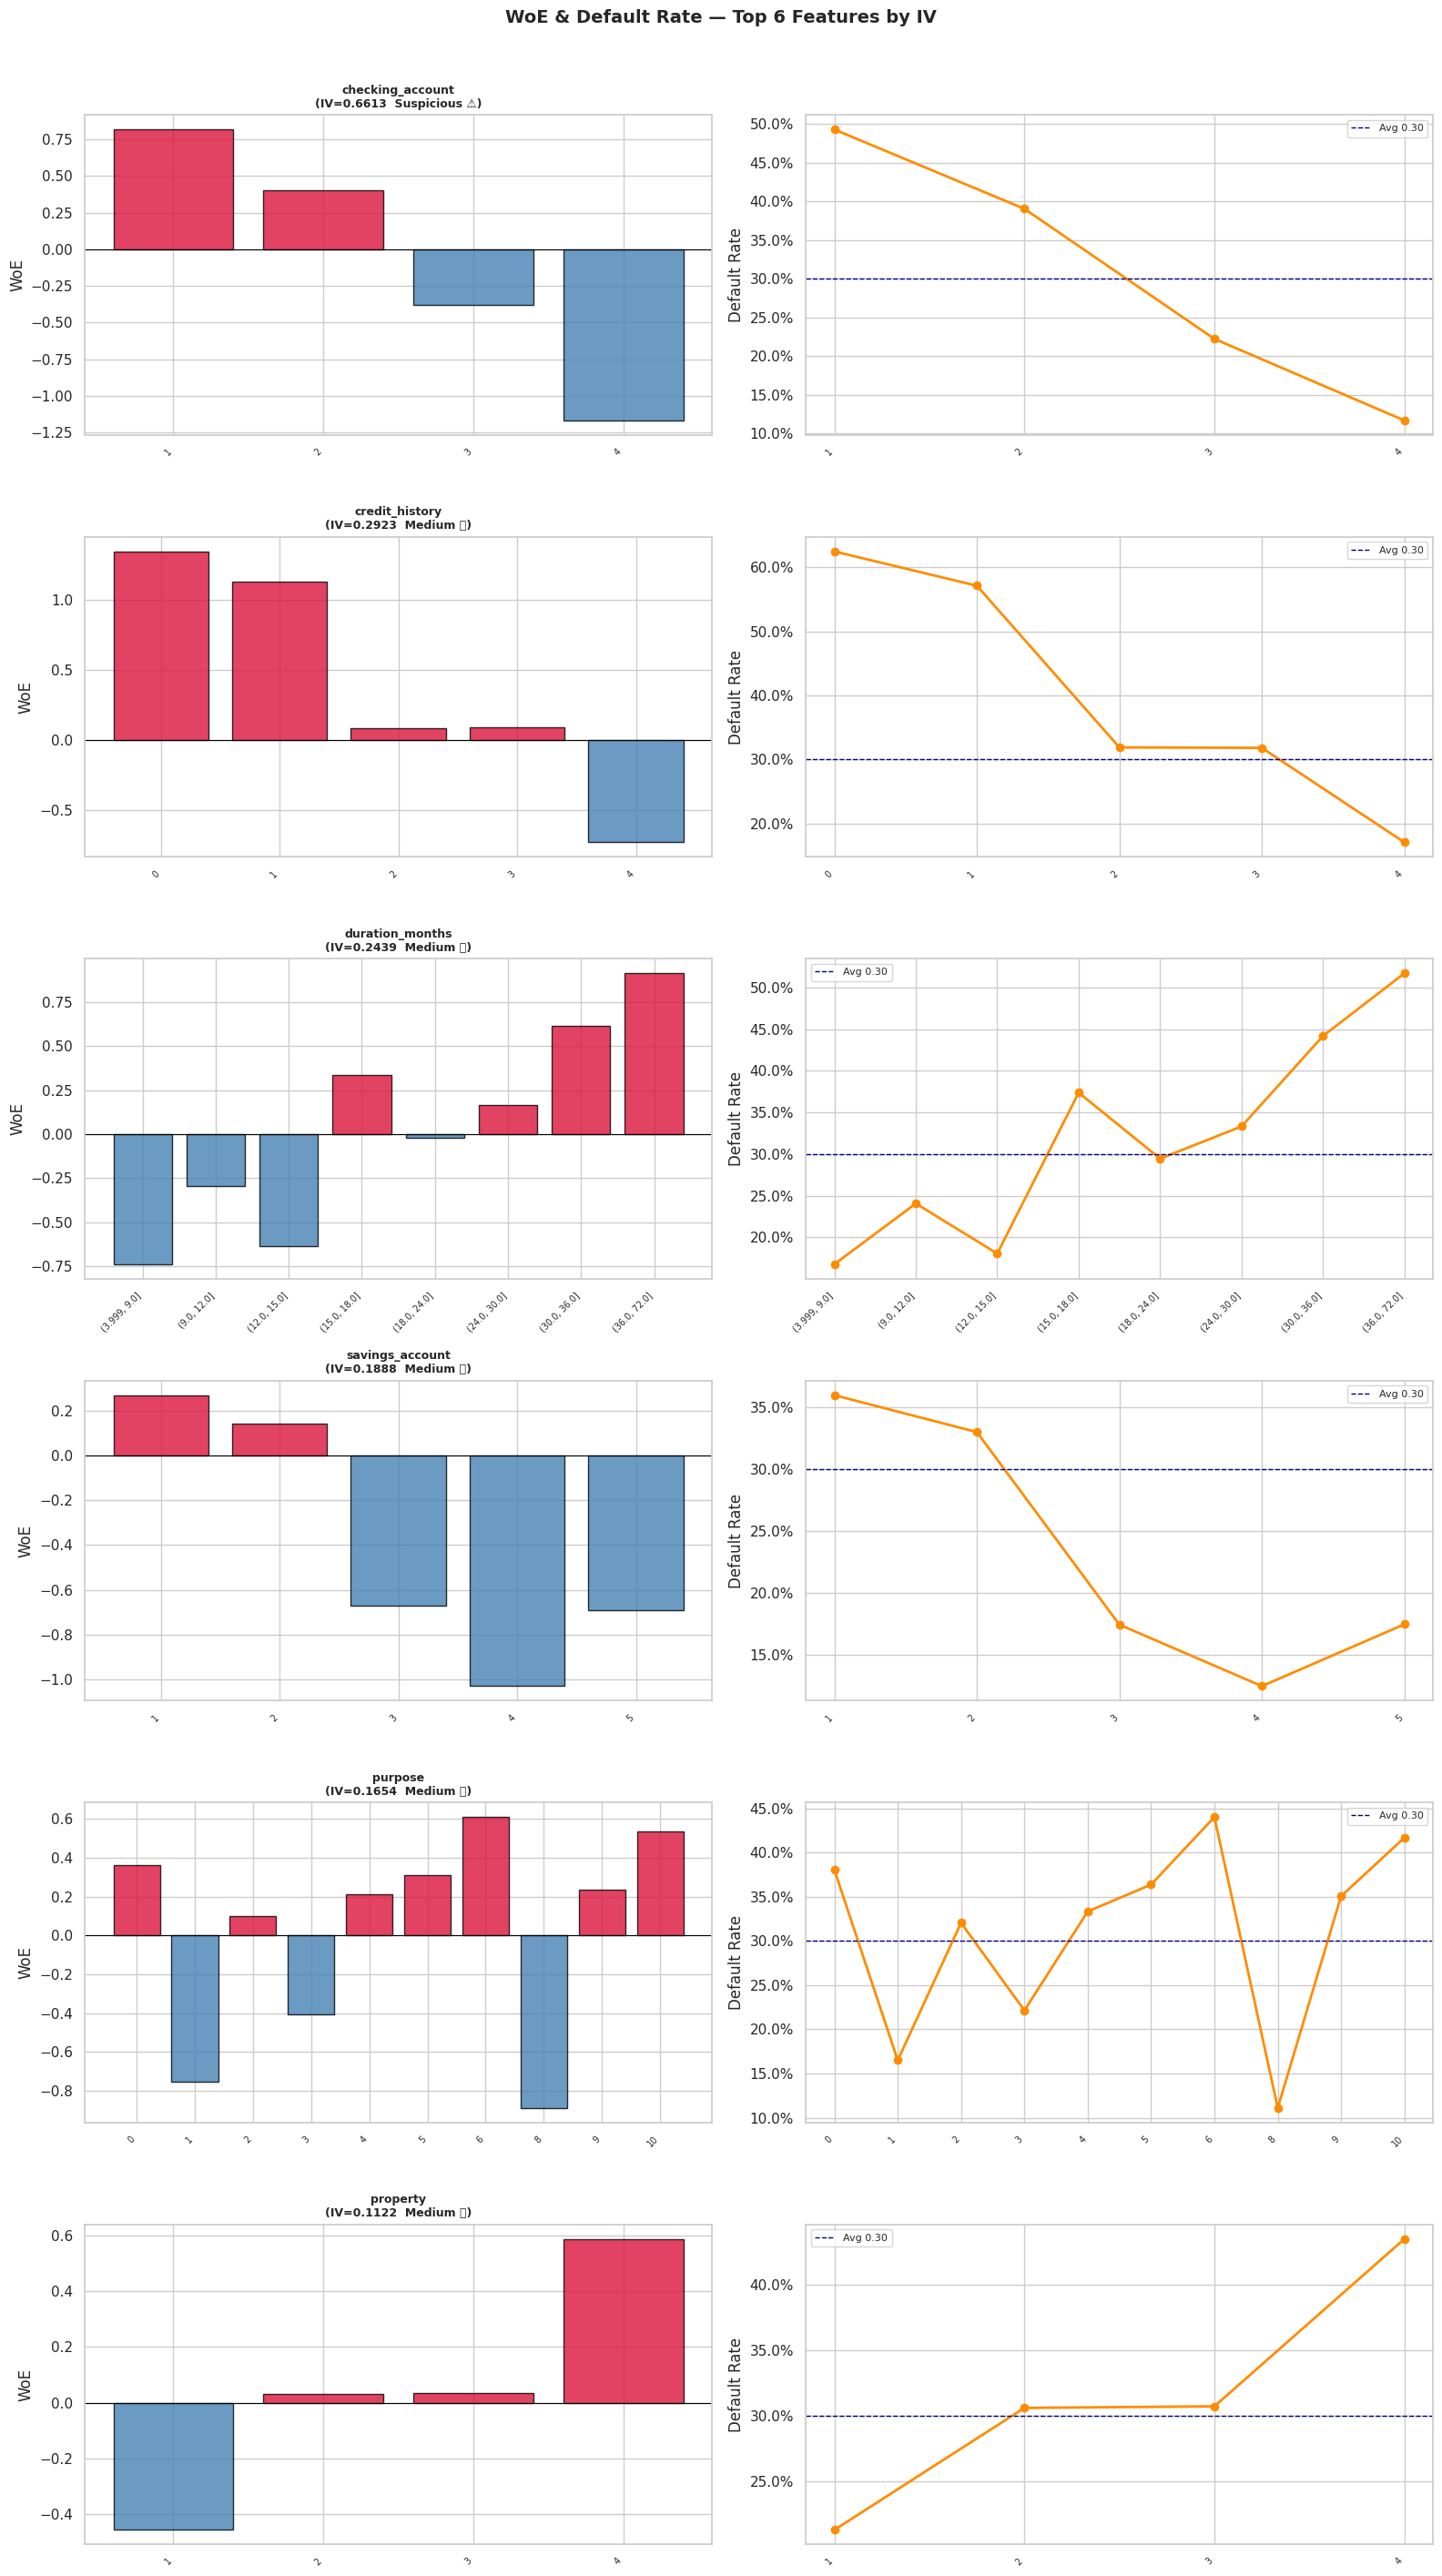

In [10]:
def plot_woe(df, feature, target, bins=10, is_numeric=True, ax_woe=None, ax_dr=None):
    """Plot WoE and Default Rate per bin for a feature."""
    woe_df, iv = compute_woe_iv(df, feature, target, bins=bins, is_numeric=is_numeric)
    bin_labels = [str(b) for b in woe_df['bin']]

    # WoE bar chart
    colors_woe = ['crimson' if w > 0 else 'steelblue' for w in woe_df['WoE']]
    ax_woe.bar(range(len(bin_labels)), woe_df['WoE'], color=colors_woe,
               edgecolor='black', alpha=0.8)
    ax_woe.axhline(0, color='black', linewidth=0.8)
    ax_woe.set_xticks(range(len(bin_labels)))
    ax_woe.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
    ax_woe.set_title(f'{feature}\n(IV={iv:.4f}  {iv_label(iv)})', fontweight='bold', fontsize=9)
    ax_woe.set_ylabel('WoE')

    # Default Rate line chart
    ax_dr.plot(range(len(bin_labels)), woe_df['Default_Rate'],
               marker='o', color='darkorange', linewidth=2)
    ax_dr.axhline(df[target].mean(), color='navy', linestyle='--',
                  linewidth=1, label=f'Avg {df[target].mean():.2f}')
    ax_dr.set_xticks(range(len(bin_labels)))
    ax_dr.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
    ax_dr.set_ylabel('Default Rate')
    ax_dr.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax_dr.legend(fontsize=8)

    return iv


# Plot top 6 features by IV
top_features = iv_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(6, 2, figsize=(16, 28))

for i, feature in enumerate(top_features):
    is_num = feature in numeric_cols
    plot_woe(data, feature, 'target', bins=10, is_numeric=is_num,
             ax_woe=axes[i][0], ax_dr=axes[i][1])

plt.suptitle('WoE & Default Rate — Top 6 Features by IV', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8 WoE Encoding — Transform the Dataset

We now **replace raw feature values with their WoE values**.

**Why?**
- Handles both numeric and categorical features uniformly
- Makes logistic regression linearly additive (log-odds scale)
- Standard practice in credit scoring systems

In [19]:
def build_woe_map(df, feature, target, bins=10, is_numeric=True):
    """Build a mapping: raw value/bin → WoE value."""
    woe_df, iv = compute_woe_iv(df, feature, target, bins=bins, is_numeric=is_numeric)
    return woe_df, iv


def apply_woe_encoding(df, features, target, bins=10):
    """
    Apply WoE encoding to selected features.
    Returns WoE-encoded DataFrame + IV summary dict.
    """
    df_woe = df.copy()
    woe_maps  = {}
    iv_summary = {}

    for feature in features:
        is_num = feature in numeric_cols
        try:
            woe_df, iv = compute_woe_iv(df, feature, target, bins=bins, is_numeric=is_num)
            iv_summary[feature] = iv

            if is_num:
                # Bin the numeric column then map to WoE
                df_woe[f'{feature}_bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df_woe[f'{feature}_bin'].map(woe_map)
                df_woe.drop(columns=[f'{feature}_bin'], inplace=True)
            else:
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df[feature].map(woe_map)

            woe_maps[feature] = woe_map

        except Exception as e:
            print(f'  !!  Skipped {feature}: {e}')

    return df_woe, woe_maps, iv_summary


# Apply WoE encoding on selected features
df_woe_encoded, woe_maps, iv_summary = apply_woe_encoding(
    data, selected_features, 'target', bins=10
)

# WoE-encoded columns
woe_cols = [f'{f}_woe' for f in selected_features if f'{f}_woe' in df_woe_encoded.columns]

print(f'WoE encoding done for {len(woe_cols)} features.')
print(f'WoE-encoded columns: {len(woe_cols)}')
df_woe_encoded[woe_cols + ['target']].head()

WoE encoding done for 15 features.
WoE-encoded columns: 15


,checking_account_woe,credit_history_woe,duration_months_woe,savings_account_woe,purpose_woe,property_woe,credit_amount_woe,age_woe,housing_woe,employment_years_woe,other_installments_woe,personal_status_woe,foreign_worker_woe,other_debtors_woe,installment_rate_woe,target
0,0.8173,-0.7268,0.3355,0.2714,0.0991,0.0315,-0.0056,0.4448,0.4060,0.4721,-0.1207,0.2365,0.0349,-0.0004,0.1579,0
1,0.8173,-0.7268,-0.7383,0.2714,0.3604,-0.4559,-0.2923,-0.5020,0.4060,0.0338,-0.1207,-0.1643,0.0349,-0.0004,-0.1881,0
2,0.4021,0.0889,-0.2958,0.1460,0.2363,-0.4559,0.0550,0.4448,0.4060,-0.3863,-0.1207,0.2365,0.0349,-0.0004,-0.1881,0
3,0.8173,-0.7268,-0.2958,0.2714,0.3604,-0.4559,0.0085,-0.2701,0.4060,0.0338,-0.1207,-0.1643,-1.1611,-0.0004,-0.0589,0
4,0.8173,-0.7268,-0.2958,0.2714,0.3604,0.0315,0.0085,-0.2701,-0.1953,0.0338,0.4853,-0.1643,-1.1611,-0.0004,0.1579,0


## 9 Save WoE-Encoded Dataset

In [20]:
# Save full WoE-encoded dataset for modeling
df_model = df_woe_encoded[woe_cols + ['target']].copy()
df_model.to_csv('german_credit_woe_encoded.csv', index=False)

print(f'WoE-encoded dataset saved ')
print(f'Shape: {df_model.shape}')
print(f'Columns: {df_model.columns.tolist()}')

WoE-encoded dataset saved 
Shape: (1000, 16)
Columns: ['checking_account_woe', 'credit_history_woe', 'duration_months_woe', 'savings_account_woe', 'purpose_woe', 'property_woe', 'credit_amount_woe', 'age_woe', 'housing_woe', 'employment_years_woe', 'other_installments_woe', 'personal_status_woe', 'foreign_worker_woe', 'other_debtors_woe', 'installment_rate_woe', 'target']


## 10 WoE Correlation Heatmap

Check correlations in WoE space — important before logistic regression.

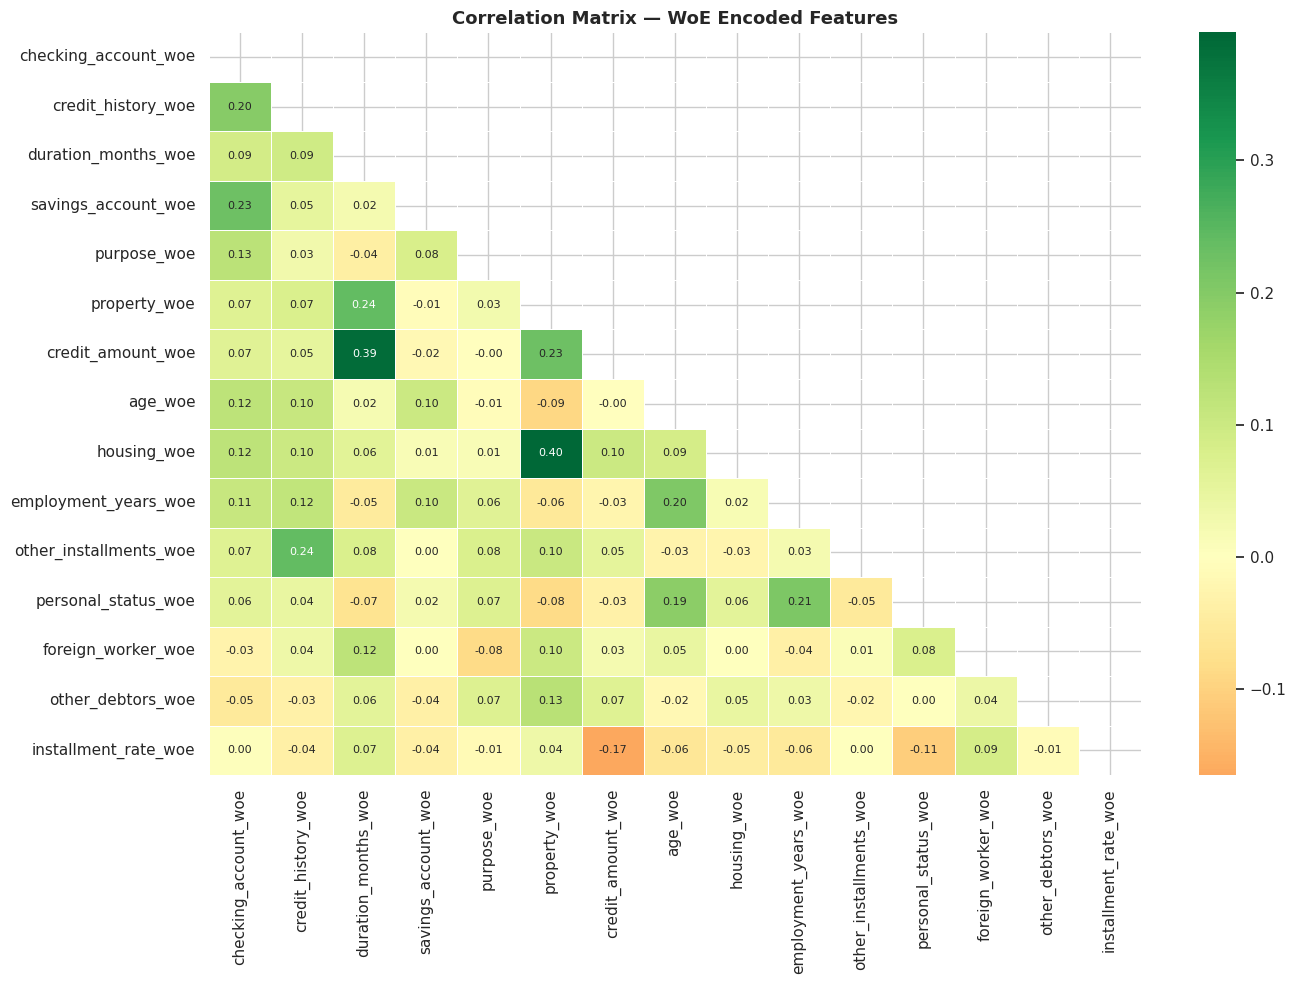


!!  Highly correlated pairs (|r| > 0.7) — potential multicollinearity:
   None found — safe to proceed to logistic regression


In [21]:
plt.figure(figsize=(14, 10))
corr = df_model[woe_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix — WoE Encoded Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7)
print('\n!!  Highly correlated pairs (|r| > 0.7) — potential multicollinearity:')
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.7:
            print(f'   {corr.columns[i]}  ↔  {corr.columns[j]}  r={corr.iloc[i,j]:.3f}')
            found = True
if not found:
    print('   None found — safe to proceed to logistic regression')

## 11 Phase 1 Summary

**What we did:**
- Computed WoE and IV for all 20 features from scratch
- Ranked features by predictive power using IV
- Dropped useless features (IV < 0.02)
- Applied WoE encoding — transformed raw values to log-odds scale
- Checked for multicollinearity in WoE space
- Saved WoE-encoded dataset for modeling

**Key Interview Talking Points:**
- *"I used WoE encoding because it handles both numeric and categorical features uniformly, deals with outliers naturally through binning, and puts features on a log-odds scale which makes logistic regression coefficients directly interpretable."*
- *"IV guided my feature selection — features below 0.02 have no discriminatory power and add noise to the model."*
- *"Positive WoE means that bin contains more defaults than the overall average — those are the risky segments."*

---
**Next Phase:** Hypothesis Testing — statistically prove that the top features are truly significant.